In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES']='1'
import sys
import random

import numpy as np
import torch
from torch.cuda.memory import set_per_process_memory_fraction
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import OneCycleLR

from gen_bert_embedding import circRNABert, seq2kmer_bert

import torch.utils.data
from transformers import BertModel, BertTokenizer
from utils import read_csv

from MyNet1 import *
from train_loop import train, validate
from utils import read_h5, myDataset, GradualWarmupScheduler, param_num, split_dataset, convert_one_hot

def seq2kmer_bert(seq, k):
    seq_length = len(seq)
    import random
    kmer = [seq[x:x + k] for x in range(seq_length - k + 1)]
    kmers = " ".join(kmer)
    return kmers


max_length = 101

# filename = sys.argv[1] + '.tsv'
# TARDBP_K562

filename = 'TIA1_Hela.tsv'
# filename = 'HNRNPM_K562.tsv'
base_path = '/home/zhuhaoran/MyNet/'

sequences, structs, label = read_csv(base_path + 'clip_data/' + filename)


# 生成bert embedding
model__path = '/home/zhuhaoran/PrismNet-master/3-new-12w-0/'  
tokenizer = BertTokenizer.from_pretrained(model__path, do_lower_case=False)
model = BertModel.from_pretrained(model__path)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
# model = torch.nn.DataParallel(model, device_ids=[0, 1, 2, 3])
model = model.eval()

structure = np.zeros((len(structs), 1, max_length))  # (N, 1, 101)
for i in range(len(structs)):
    struct = structs[i].split(',')
    ti = [float(t) for t in struct]
    ti = np.array(ti).reshape(1, -1)
    structure[i] = np.concatenate([ti], axis=0)

# test_struc = structure
# test_emb = bert_embedding
# test_label = label

[train_seq, train_struc, train_label], [test_seq, test_struc, test_label] = \
    split_dataset(sequences, structure, label, valid_frac=1/30)  # , test_size=0.2, shuffle=True, stratify=label)

test_emb = circRNABert(list(test_seq), model, tokenizer, device, 3)  # default k=3  # (N, 101, 768)
test_emb = test_emb.transpose([0, 2, 1])  # (N, 768, 101)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MyNet10_tsne().to(device)

model_file = '/home/zhuhaoran/MyNet/out/out1/' + filename + '_best.pth'
model.load_state_dict(torch.load(model_file))

test_set = myDataset(test_emb, test_struc, test_label)

test_loader = DataLoader(test_set, batch_size=32 * 8, shuffle=False)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(2))

model.eval()
y_all = []
p_all = []
l_all = []
yyy= []


down_up_sample = []
multi_view_sample = []
dpcnn_sample = []

with torch.no_grad():
    for batch_idx, (x0, x00, y0) in enumerate(test_loader):
        x, s, y = x0.float().to(device), x00.float().to(device), y0.to(device).float()
        # if y0.sum() ==0:
        #    import pdb; pdb.set_trace()
        down_up, multi_view, [dpcnn, output] = model(x, s)
        loss = criterion(output, y)
        prob = torch.sigmoid(output)  # 将输出控制到[0,1]
        # print(output, prob, y)  # 一个batch

        y_np = y.to(device='cpu', dtype=torch.long).numpy()
        p_np = prob.to(device='cpu').numpy()


        down_up = down_up.to(device='cpu', dtype=torch.long).numpy()
        multi_view = multi_view.to(device='cpu', dtype=torch.long).numpy()
        dpcnn = dpcnn.to(device='cpu', dtype=torch.long).numpy()

        down_up_sample.append(down_up)
        multi_view_sample.append(multi_view)
        dpcnn_sample.append(dpcnn)


        l_np = loss.item()

        y_all.append(y_np)
        p_all.append(p_np)
        l_all.append(l_np)
        yyy.append(output.to(device='cpu', dtype=torch.long).numpy())



y_all = np.concatenate(y_all)
p_all = np.concatenate(p_all)
yyy = np.concatenate(yyy)
down_up_sample = np.concatenate(down_up_sample)
multi_view_sample = np.concatenate(multi_view_sample)
dpcnn_sample = np.concatenate(dpcnn_sample)
l_all = np.array(l_all)


# bert_embedding = circRNABert(list(sequences), model, tokenizer, device, 3)  # default k=3  # (N, 101, 768)
# bert_embedding = bert_embedding.transpose([0, 2, 1])  # (N, 768, 101)

Some weights of the model checkpoint at /home/zhuhaoran/PrismNet-master/3-new-12w-0/ were not used when initializing BertModel: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
/home/zhuhaoran/anaconda3/envs/graph-bert/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:2301: FutureWarning: The `pad_to_max_length` a

/home/zhuhaoran/anaconda3/envs/graph-bert/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/home/zhuhaoran/anaconda3/envs/graph-bert/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


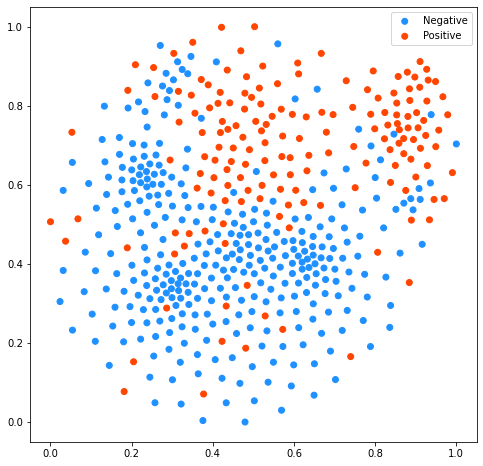

In [10]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
np.random.seed(5)
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(multi_view_sample)

x_min, x_max = X_tsne.min(0), X_tsne.max(0)
X_norm = (X_tsne-x_min)/(x_max-x_min) 




plt.figure(figsize=(8, 8))
from matplotlib import cm
#cplt.subplot(121)
# colors = cm.Set1([0,1])
colors = np.array(["dodgerblue", "orangered"])
labels = ["Negative", "Positive"]
for label in labels:
    if label=="Negative":
        index = np.where(test_label==0)
    else:
        index = np.where(test_label==1)
    plt.scatter(X_norm[index[0], 0], X_norm[index[0], 1], c=colors[test_label.squeeze().astype(int)[index[0]]],label=label)

# plt.show()
plt.legend()

In [3]:
down_up_sample.shape

(499, 25344)